In [1]:
import sys
from pathlib import Path
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
import json

from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    adjusted_rand_score,
    normalized_mutual_info_score,
)

from src.constants import (
    TARGET_COL,
    MULTILABEL_COLS,
    CATEGORICAL_COLS,
    CLASS_LABELS,
    RANDOM_STATE,
    PROCESSED_DATA_PATH,
)
from src.preprocessing import load_processed_dataset, validate_processed_dataset
from src.encoders import fit_mlb_encoder, fit_ohe_encoder, build_mlb_ohe_matrix, ARTIFACTS_PATH, save_encoders
from src.visualisations import plot_cluster_distribution

In [2]:
k_range = range(2, 11)
KMEANS_INIT = "k-means++"
N_INIT_GRID = 20
N_INIT_FINAL = 50

In [3]:
df = load_processed_dataset(PROCESSED_DATA_PATH)
validate_processed_dataset(df)

# Fit encoders on the full data (no held-out set in unsupervised analysis)
mlb_encoder = fit_mlb_encoder(df, MULTILABEL_COLS)
ohe_encoder = fit_ohe_encoder(df, CATEGORICAL_COLS)

# Build the MLB + OHE feature matrix for KMeans (fully numeric)
X_cluster = build_mlb_ohe_matrix(df, mlb_encoder, ohe_encoder).astype(float)

# True labels for post-hoc evaluation against decision_taken
y_true = df[TARGET_COL].astype(str).reset_index(drop=True)

# Keep raw categorical columns alongside for cluster characterisation later
df_raw = df[MULTILABEL_COLS + CATEGORICAL_COLS + [TARGET_COL]].reset_index(drop=True)

print(f"KMeans input matrix shape: {X_cluster.shape}")
print(f"OHE categorical columns: {len(ohe_encoder.get_feature_names_out(CATEGORICAL_COLS))}")
print(f"MLB multi-valued columns: {sum(len(encoder.classes_) for encoder in mlb_encoder.values())}")

for col, encoder in mlb_encoder.items():
    print(f"\t{col}: {len(encoder.classes_)} unique labels")

assert X_cluster.isnull().sum().sum() == 0, "Null values found in KMeans feature matrix"
print("\nNo nulls in cluster matrix")

KMeans input matrix shape: (9250, 59)
OHE categorical columns: 34
MLB multi-valued columns: 25
	data_subject_type: 9 unique labels
	data_type: 16 unique labels

No nulls in cluster matrix


In [4]:
print(f"Feature matrix preview:\n{pd.DataFrame(X_cluster).head()}")

print(f"Feature columns:\n{pd.DataFrame(X_cluster).columns}")

Feature matrix preview:
   incident_category_Cyber  incident_category_Non Cyber  \
0                      0.0                          1.0   
1                      0.0                          1.0   
2                      0.0                          1.0   
3                      0.0                          1.0   
4                      0.0                          1.0   

   incident_type_Alteration of personal data  incident_type_Brute Force  \
0                                        0.0                        0.0   
1                                        0.0                        0.0   
2                                        0.0                        0.0   
3                                        0.0                        0.0   
4                                        0.0                        0.0   

   incident_type_Data emailed to incorrect recipient  \
0                                                0.0   
1                                                0.0   
2 

In [5]:
kmeans_inertias    = []
kmeans_silhouettes = []
kmeans_k_search_rows = []

for k in k_range:
    kmeans = KMeans(
        n_clusters=k,
        init=KMEANS_INIT,
        n_init=N_INIT_GRID,
        random_state=RANDOM_STATE)
    
    labels = kmeans.fit_predict(X_cluster)
    
    kmeans_inertias.append(float(kmeans.inertia_))
    silhouette = silhouette_score(X_cluster, labels, metric="euclidean")
    kmeans_silhouettes.append(silhouette)
    
    kmeans_k_search_rows.append({
        "k": k,
        "inertia": kmeans.inertia_,
        "silhouette": silhouette
    })
    
    print(f"K={k}: Inertia={kmeans.inertia_:.1f}, Silhouette={silhouette:.4f}")
    
kmeans_k_search_results = pd.DataFrame(kmeans_k_search_rows)
display(kmeans_k_search_results)

K=2: Inertia=32109.3, Silhouette=0.1475
K=3: Inertia=29783.6, Silhouette=0.1431
K=4: Inertia=28213.2, Silhouette=0.1240
K=5: Inertia=26605.6, Silhouette=0.1452
K=6: Inertia=25158.6, Silhouette=0.1449
K=7: Inertia=24187.6, Silhouette=0.1556
K=8: Inertia=23499.6, Silhouette=0.1444
K=9: Inertia=22932.2, Silhouette=0.1448
K=10: Inertia=22520.4, Silhouette=0.1429


,k,inertia,silhouette
0,2,32109.278124,0.147547
1,3,29783.649529,0.143127
2,4,28213.213304,0.124007
3,5,26605.559371,0.145233
4,6,25158.552985,0.144916
5,7,24187.620262,0.155590
6,8,23499.648895,0.144446
7,9,22932.168435,0.144751
8,10,22520.426258,0.142914


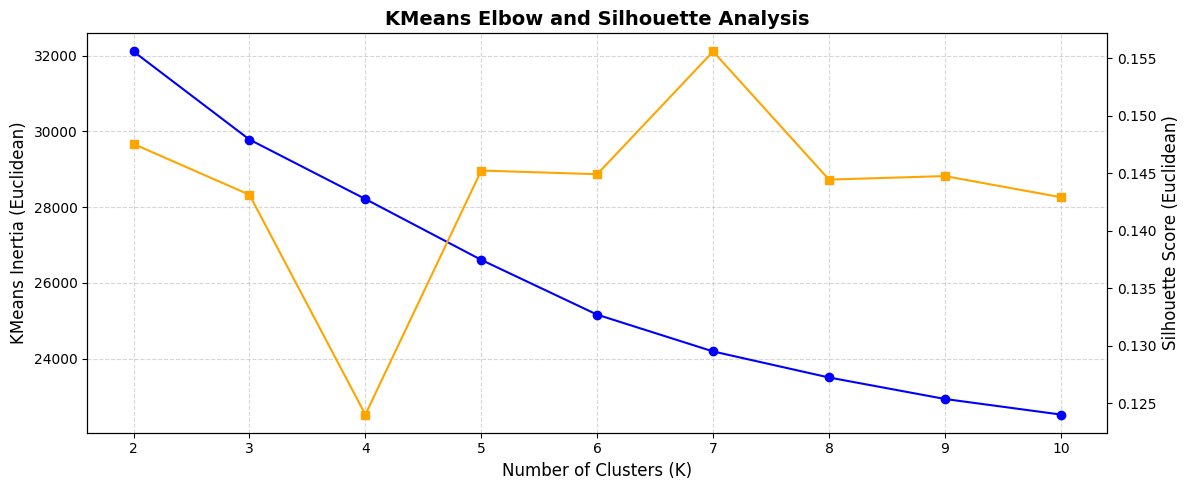

K with highest silhouette: K=7, score=0.1556
Controlled final K for comparison with Kmodes: K=7


In [6]:
fig, ax_inertia = plt.subplots(figsize=(12, 5))

ax_inertia.set_xlabel("Number of Clusters (K)", fontsize=12)
ax_inertia.set_ylabel("KMeans Inertia (Euclidean)", fontsize=12)
ax_inertia.plot(list(k_range), kmeans_inertias, marker="o", label="Inertia", color="blue")
ax_inertia.tick_params(axis="y")
ax_inertia.grid(True, axis="both", linestyle="--", alpha=0.5)

ax_silhouette = ax_inertia.twinx()
ax_silhouette.set_ylabel("Silhouette Score (Euclidean)", fontsize=12)
ax_silhouette.plot(list(k_range), kmeans_silhouettes, marker="s", label="Silhouette", color="orange")
ax_silhouette.tick_params(axis="y")

plt.title("KMeans Elbow and Silhouette Analysis", fontsize=14, fontweight="bold")
fig.tight_layout()
plt.show()

best_silhouette_idx = int(np.argmax(kmeans_silhouettes))
best_silhouette_k = list(k_range)[best_silhouette_idx]
best_silhouette_score = kmeans_silhouettes[best_silhouette_idx]

print(f"K with highest silhouette: K={best_silhouette_k}, score={best_silhouette_score:.4f}")
print(f"Controlled final K for comparison with Kmodes: K={best_silhouette_k}")

In [7]:
final_k = best_silhouette_k

print(f"Fitting final KMeans with K={final_k}")
kmeans_final = KMeans(
    n_clusters=final_k,
    init=KMEANS_INIT,
    n_init=N_INIT_FINAL,
    random_state=RANDOM_STATE,
)

kmeans_labels = kmeans_final.fit_predict(X_cluster)

print(f"\nCluster sizes:")
sizes = pd.Series(kmeans_labels).value_counts().sort_index()
for cluster_id, count in sizes.items():
    print(f"\tCluster {cluster_id}: {count} breaches ({count/len(kmeans_labels)*100:.1f}%)")

print(f"\nFinal inertia: {kmeans_final.inertia_:.1f}")
final_silhouette = silhouette_score(X_cluster, kmeans_labels, metric="euclidean")
print(f"Final silhouette score: {final_silhouette:.4f}")

Fitting final KMeans with K=7

Cluster sizes:
	Cluster 0: 1679 breaches (18.2%)
	Cluster 1: 847 breaches (9.2%)
	Cluster 2: 661 breaches (7.1%)
	Cluster 3: 2353 breaches (25.4%)
	Cluster 4: 1667 breaches (18.0%)
	Cluster 5: 737 breaches (8.0%)
	Cluster 6: 1306 breaches (14.1%)

Final inertia: 24187.6
Final silhouette score: 0.1556


In [8]:
df_analysis = df_raw.copy()
df_analysis["cluster"] = kmeans_labels

print("Per-cluster feature dominance:")
for cluster_id in range(final_k):
    cluster_rows = df_analysis[df_analysis["cluster"] == cluster_id]
    print(f"\nCluster {cluster_id} ({len(cluster_rows)} breaches, {len(cluster_rows)/len(df_analysis)*100:.1f}%)")
    
    for col in MULTILABEL_COLS + CATEGORICAL_COLS:
        top = cluster_rows[col].value_counts(normalize=True).head(1)
        if len(top) > 0:
            value, prop = top.index[0], top.iloc[0]
            print(f"\t{col}: {value} ({prop*100:.1f}%)")

    decision_distribution = cluster_rows[TARGET_COL].value_counts(normalize=True)
    print(f"\ndecision outcomes within cluster")
    for label in CLASS_LABELS:
        prop = decision_distribution.get(label, 0.0)
        print(f"\t{label}: {prop*100:.1f}%")

Per-cluster feature dominance:

Cluster 0 (1679 breaches, 18.2%)
	data_subject_type: Patients (62.4%)
	data_type: Basic personal identifiers, Health data (54.6%)
	incident_category: Non Cyber (99.9%)
	incident_type: Data emailed to incorrect recipient (24.7%)
	no_data_subjects_affected: 1 to 9 (78.9%)
	time_taken_to_report: Less than 24 hours (100.0%)

decision outcomes within cluster
	Informal Action Taken: 91.7%
	Investigation Pursued: 3.6%
	No Further Action: 4.7%

Cluster 1 (847 breaches, 9.2%)
	data_subject_type: Patients (50.5%)
	data_type: Unknown (99.9%)
	incident_category: Non Cyber (99.5%)
	incident_type: Other non-cyber incident (29.3%)
	no_data_subjects_affected: 1 to 9 (73.3%)
	time_taken_to_report: 24 hours to 72 hours (35.3%)

decision outcomes within cluster
	Informal Action Taken: 77.4%
	Investigation Pursued: 6.3%
	No Further Action: 16.3%

Cluster 2 (661 breaches, 7.1%)
	data_subject_type: Unknown (95.9%)
	data_type: Unknown (96.2%)
	incident_category: Non Cyber (71.

In [9]:
ari = adjusted_rand_score(y_true, kmeans_labels)
nmi = normalized_mutual_info_score(y_true, kmeans_labels)

print(f"Cluster vs Decision Taken alignment:")
print(f"\tAdjusted Rand Index: {ari:.4f}")
print(f"\tNormalised Mutual Info: {nmi:.4f}")

# Sanity baseline: shuffle the labels and recompute. Should be near 0.
rng = np.random.default_rng(RANDOM_STATE)
shuffled_labels = rng.permutation(kmeans_labels)
ari_shuffled = adjusted_rand_score(y_true, shuffled_labels)
nmi_shuffled = normalized_mutual_info_score(y_true, shuffled_labels)

print(f"\nRandom-shuffle baseline:")
print(f"\tARI: {ari_shuffled:.4f}")
print(f"\tNMI: {nmi_shuffled:.4f}")

if ari < 0.05:
    print("\nInterpretation: clusters do NOT meaningfully align with ICO decisions.")
elif ari < 0.15:
    print("\nInterpretation: weak alignment between clusters and ICO decisions.")
else:
    print("\nInterpretation: moderate or strong alignment between clusters and decisions.")

Cluster vs Decision Taken alignment:
	Adjusted Rand Index: 0.0357
	Normalised Mutual Info: 0.0454

Random-shuffle baseline:
	ARI: -0.0009
	NMI: 0.0006

Interpretation: clusters do NOT meaningfully align with ICO decisions.


Cluster vs decision_taken (counts):
decision_taken  Informal Action Taken  Investigation Pursued  No Further Action   All
cluster                                                                              
0                                1539                     61                 79  1679
1                                 656                     53                138   847
2                                 438                     61                162   661
3                                2123                    134                 96  2353
4                                1438                    135                 94  1667
5                                 353                     65                319   737
6                                1123                     89                 94  1306
All                              7670                    598                982  9250

Row proportions within each cluster:
decision_taken  Informal Action Taken  Investigation Pursued  No F

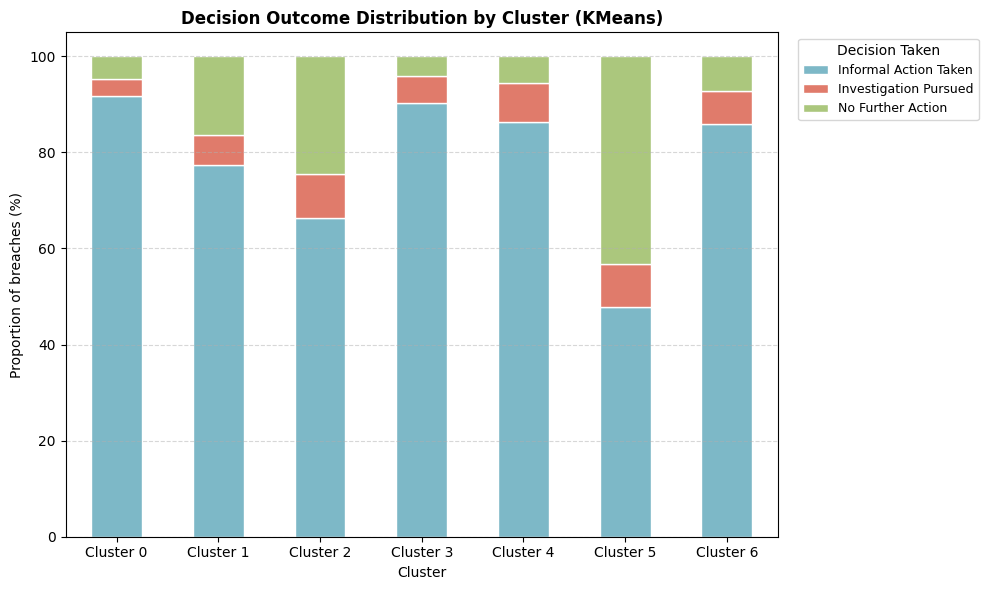

decision_taken,Informal Action Taken,Investigation Pursued,No Further Action
cluster,,,
0,0.916617,0.036331,0.047052
1,0.774498,0.062574,0.162928
2,0.662632,0.092284,0.245083
3,0.902252,0.056949,0.040799
4,0.862627,0.080984,0.056389
5,0.478969,0.088195,0.432836
6,0.859877,0.068147,0.071975


In [10]:
# Cluster vs decision_taken, descriptive cross-tab
print("Cluster vs decision_taken (counts):")
counts = pd.crosstab(df_analysis["cluster"], df_analysis[TARGET_COL], margins=True)
print(counts.to_string())

print("\nRow proportions within each cluster:")
row_proportions = pd.crosstab(
    df_analysis["cluster"],
    df_analysis[TARGET_COL],
    normalize="index"
    ).reindex(columns=CLASS_LABELS, fill_value=0).round(4)
print(row_proportions.to_string())

# Stacked bar visualisation using the shared helper
plot_cluster_distribution(
    cluster_labels=kmeans_labels,
    decision_labels=df_analysis[TARGET_COL],
    class_labels=CLASS_LABELS,
    title="Decision Outcome Distribution by Cluster (KMeans)",
)

In [11]:
assert len(kmeans_labels) == len(X_cluster), "Label/ row count mismatch"
print(f"Every row assigned a cluster label ({len(kmeans_labels)} labels)")

assert len(np.unique(kmeans_labels)) == final_k, f"Expected {final_k} clusters, found {len(np.unique(kmeans_labels))}"
print(f"K={final_k} matches actual unique clusters")

unique, counts = np.unique(kmeans_labels, return_counts=True)
assert (counts > 0).all(), "Empty clusters found"
print(f"No empty clusters (sizes: {dict(zip(unique.tolist(), counts.tolist()))})")

assert ari >= -0.05, f"ARI unexpectedly negative ({ari:.4f})"
print(f"ARI ({ari:.4f}) is at or above random baseline")

Every row assigned a cluster label (9250 labels)
K=7 matches actual unique clusters
No empty clusters (sizes: {0: 1679, 1: 847, 2: 661, 3: 2353, 4: 1667, 5: 737, 6: 1306})
ARI (0.0357) is at or above random baseline


In [12]:
kmeans_summary = {
    "model": "KMeans MLB+OHE",
    "feature_representation": "OHE categorical columns + MLB multi-valued columns",
    "k": int(final_k),
    "n_features": int(X_cluster.shape[1]),
    "n_rows": int(X_cluster.shape[0]),
    "n_init_grid": int(N_INIT_GRID),
    "n_init_final": int(N_INIT_FINAL),
    "random_state": int(RANDOM_STATE),
    "ari": round(float(ari), 4),
    "nmi": round(float(nmi), 4),
    "silhouette_euclidean": round(float(final_silhouette), 4),
    "inertia": round(float(kmeans_final.inertia_), 2),
    "best_silhouette_k_from_search": int(best_silhouette_k),
    "best_silhouette_score_from_search": round(float(best_silhouette_score), 4),
}

print("KMeans summary for comparison with KModes notebook:")
for key, value in kmeans_summary.items():
    print(f"\t{key}: {value}")

KMeans summary for comparison with KModes notebook:
	model: KMeans MLB+OHE
	feature_representation: OHE categorical columns + MLB multi-valued columns
	k: 7
	n_features: 59
	n_rows: 9250
	n_init_grid: 20
	n_init_final: 50
	random_state: 42
	ari: 0.0357
	nmi: 0.0454
	silhouette_euclidean: 0.1556
	inertia: 24187.62
	best_silhouette_k_from_search: 7
	best_silhouette_score_from_search: 0.1556


In [13]:
artifacts_path = Path(ARTIFACTS_PATH)
artifacts_path.mkdir(parents=True, exist_ok=True)

cluster_path = artifacts_path / "clustering"
cluster_path.mkdir(parents=True, exist_ok=True)

with open(cluster_path / "kmeans_final.pkl", "wb") as f:
    pickle.dump(kmeans_final, f)

save_encoders(mlb_encoder, ohe_encoder, cluster_path)

kmeans_k_search_results.to_csv(cluster_path / "kmeans_k_search_results.csv", index=False)

with open(cluster_path / "kmeans_summary.json", "w") as f:
    json.dump(kmeans_summary, f, indent=2)

cluster_characteristics = {}
for cluster_id in range(final_k):
    cluster_rows = df_analysis[df_analysis["cluster"] == cluster_id]
    outcome_distribution = cluster_rows[TARGET_COL].value_counts(normalize=True)

    top_features = {}
    for col in MULTILABEL_COLS + CATEGORICAL_COLS:
        top = cluster_rows[col].value_counts(normalize=True).head(3)
        top_features[col] = {
            str(value): round(float(prop) * 100, 1)
            for value, prop in top.items()
        }

    cluster_characteristics[str(cluster_id)] = {
        "size": int(len(cluster_rows)),
        "percentage_of_dataset": round(float(len(cluster_rows) / len(df_analysis) * 100), 1),
        "outcome_distribution": {
            label: round(float(outcome_distribution.get(label, 0.0)) * 100, 1)
            for label in CLASS_LABELS
        },
        "top_features": top_features
    }

with open(cluster_path / "kmeans_cluster_characteristics.json", "w") as f:
    json.dump(cluster_characteristics, f, indent=2)

feature_metadata = {
    "feature_columns_order": list(X_cluster.columns),
    "multilabel_columns": MULTILABEL_COLS,
    "categorical_columns": CATEGORICAL_COLS,
    "target_column": TARGET_COL
}
with open(cluster_path / "kmeans_feature_metadata.json", "w") as f:
    json.dump(feature_metadata, f, indent=2)

print(f"Saved KMeans artifacts to {cluster_path}/")
for path in sorted(cluster_path.glob("kmeans*")):
    print(f"\t{path}")


Saved KMeans artifacts to ..\artifacts\clustering/
	..\artifacts\clustering\kmeans_cluster_characteristics.json
	..\artifacts\clustering\kmeans_feature_metadata.json
	..\artifacts\clustering\kmeans_final.pkl
	..\artifacts\clustering\kmeans_k_search_results.csv
	..\artifacts\clustering\kmeans_summary.json
